# Manutenção preditiva — B-8802B: como o sistema funciona e o que ele entregou

Este notebook gera as figuras e os números da apresentação `apresentacao_simpred_b8802b.pptx`, na mesma ordem
dos slides. Usa o modelo em produção (`deploy_v2/Transpetro/B-8802B-2025`), treinado com os 12 meses de 2025,
e os dados reais do equipamento de 2022 e de 2025–26.

**Como funciona, em 4 passos** (slide 2)
1. **Aprende o normal:** um modelo de IA (autoencoder) estuda 12 meses de operação normal: como pressões,
   vibrações e temperaturas se comportam juntas.
2. **Vigia todo dia:** compara os sensores com esse normal. Se eles se afastam por mais de 1 hora, gera um alerta
   para a operação verificar.
3. **Percebe quando o normal muda:** depois de uma manutenção, o normal do equipamento pode mudar. Um monitor
   semanal (`scripts/monitor_drift.py`) percebe isso em poucos dias.
4. **Reaprende com confirmação:** a operação confirma que é um normal novo; o sistema retreina sozinho
   (`scripts/retrain_pipeline.py`) e testa o modelo novo antes de colocá-lo em uso (`scripts/battery.py`).

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.dates as mdates
warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists(): PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
DEP = PROJECT_ROOT / "deploy_v2/Transpetro"; sys.path.insert(0, str(DEP))
import simpred_inference as si
from transpetro_modelos.drift import battery, monitor as mon
from transpetro_modelos.drift.detectors import CalibratedKSDetector

B = DEP / "B-8802B-2025/modelos/model_2025-01-01_2026-08-10_VAE"          # modelo em produção (treino: 2025)
B_ANTIGO = DEP / "B-8802B/modelos/model_2022-05-15_2022-07-21_VAE"         # modelo de 2022
modelo = si.carregar_modelo(B)
raw = si.carregar_dados(DEP / "B-8802B-2025/dados/2025_2026/data_2025-01-01_2026-08-10_raw.csv")
raw22 = si.carregar_dados(next((DEP / "B-8802B/dados").rglob("*_raw.csv")))
faixa = json.loads((B / "clip_bounds.json").read_text())                  # faixa normal aprendida em 2025 (p1–p99,9)

def alertas(df):
    """Alarme do modelo em produção, instante a instante."""
    return si.prever(B, modelo, si.preprocessar(B, df))["is_anomaly"]

def min_duracao(al, horas=1.0):
    """Regra de 1 hora (proposta): um episódio só vira alerta se durar ≥ `horas`, e só a partir daí."""
    out = pd.Series(False, index=al.index); a = al[al]
    if a.empty: return out
    g = (a.index.to_series().diff() > pd.Timedelta(hours=12)).cumsum()
    for _, e in a.groupby(g):
        if (e.index.max() - e.index.min()) >= pd.Timedelta(hours=horas):
            out[e.index[e.index >= e.index.min() + pd.Timedelta(hours=horas)]] = True
    return out

def episodios(al):
    a = al[al]
    if a.empty: return []
    g = (a.index.to_series().diff() > pd.Timedelta(hours=12)).cumsum()
    return [(e.index.min(), e.index.max()) for _, e in a.groupby(g)]

def horaria(df, cols):
    """Média horária só com a bomba operando; horas paradas ficam vazias (a linha quebra)."""
    return df[df["Pressão Descarga"] > 35][cols].resample("1h").mean()

COLS = ["Vibração Bomba LA", "Vibração Bomba LNA", "Temperatura Bomba LA"]
NOMES = {"Vibração Bomba LA": "Vibração mancal LA (mm/s)", "Vibração Bomba LNA": "Vibração mancal LNA (mm/s)",
         "Temperatura Bomba LA": "Temperatura mancal LA (°C)"}
rotulo = lambda c: NOMES[c].split(" (")[0].replace(" mancal", "\nmancal")
print("dados e modelo carregados")

dados e modelo carregados


## Slide 3 — Treinado com 2025, testado em 2026

2026 nunca foi usado no treino: é o teste do modelo em dados novos. A faixa verde é o normal que o modelo
aprendeu em 2025. Os números usam a regra de 1 hora (proposta); o cálculo sem ela aparece logo abaixo.

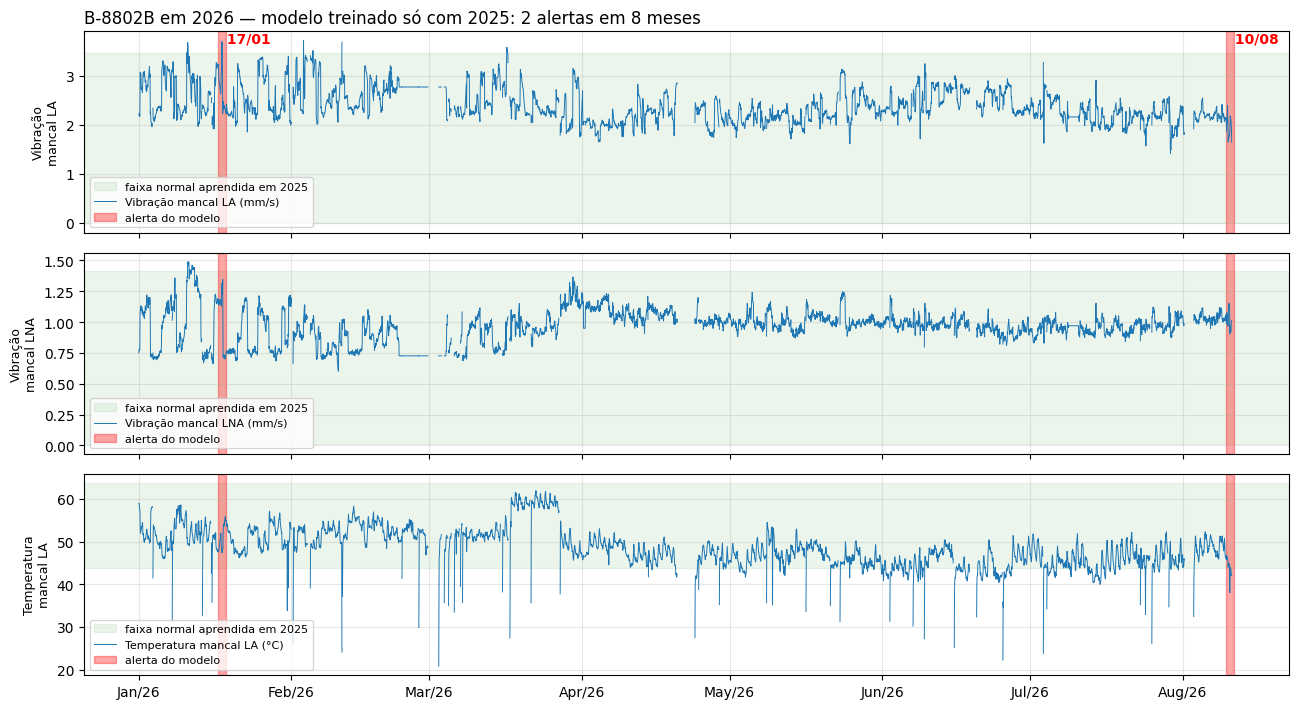

tempo sem alerta em 2026: 99.98 %   (sem a regra de 1 h: 99.92 %, 3 alertas)
alerta 17/01/2026 22:30: sensor fora da faixa normal → Vibração Bomba LA
alerta 10/08/2026 13:45: sensor fora da faixa normal → Temperatura Bomba LA


In [2]:
al_todo = alertas(raw)
al26_sem_regra = al_todo[al_todo.index >= "2026-01-01"]
al26 = min_duracao(al_todo)[lambda s: s.index >= "2026-01-01"]
eps = episodios(al26)

h = horaria(raw.loc["2026-01-01":], COLS)
fig, axes = plt.subplots(3, 1, figsize=(13, 7.2), sharex=True)
for ax, c in zip(axes, COLS):
    lo, hi = faixa[c]
    ax.axhspan(lo, hi, color="green", alpha=0.08, label="faixa normal aprendida em 2025")
    ax.plot(h.index, h[c], linewidth=0.7, label=NOMES[c])
    for i, (a, b) in enumerate(eps):
        ax.axvspan(a - pd.Timedelta(hours=18), b + pd.Timedelta(hours=18), color="red", alpha=0.35, label="alerta do modelo" if i == 0 else None)
    ax.set_ylabel(rotulo(c), fontsize=9); ax.grid(alpha=0.3); ax.legend(loc="lower left", fontsize=8)
for (a, b) in eps:
    axes[0].text(a, axes[0].get_ylim()[1], f" {a:%d/%m}", color="red", fontsize=10, va="top", fontweight="bold")
axes[0].set_title(f"B-8802B em 2026 — modelo treinado só com 2025: {len(eps)} alertas em 8 meses", loc="left")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b/%y")); plt.tight_layout(); plt.show()

print(f"tempo sem alerta em 2026: {100 * (1 - al26.mean()):.2f} %   (sem a regra de 1 h: {100 * (1 - al26_sem_regra.mean()):.2f} %, "
      f"{len(episodios(al26_sem_regra))} alertas)")
for a, b in eps:
    w = raw.loc[a:b]; w = w[w["Pressão Descarga"] > 35]
    fora = [c for c, (lo, hi) in faixa.items() if c in w and ((w[c] < lo) | (w[c] > hi)).mean() > 0.5]
    print(f"alerta {a:%d/%m/%Y %H:%M}: sensor fora da faixa normal → {', '.join(fora) or 'nenhum'}")

## Slide 4 — Ele detecta falha de verdade

Em 2022 a bomba falhou por uma trinca no acoplamento. O modelo foi treinado só com 2025 e nunca viu esses dados.

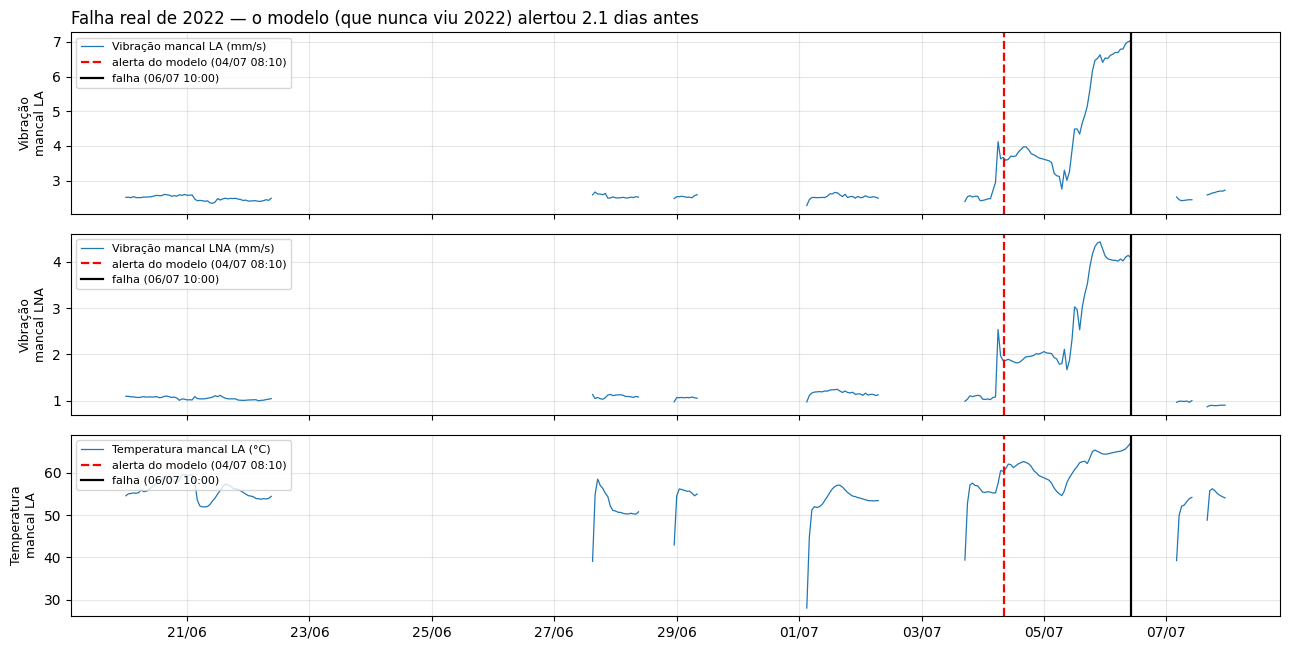

antecedência na falha real de 2022: 2.1 dias


In [3]:
FALHA = pd.Timestamp("2022-07-06 10:00")
al22 = min_duracao(alertas(raw22))
primeiro = al22[(al22.index >= "2022-06-29") & al22].index.min()
h = horaria(raw22.loc["2022-06-20":"2022-07-07"], COLS)
fig, axes = plt.subplots(3, 1, figsize=(13, 6.6), sharex=True)
for ax, c in zip(axes, COLS):
    ax.plot(h.index, h[c], linewidth=0.9, label=NOMES[c])
    ax.axvline(primeiro, color="red", linestyle="--", linewidth=1.6, label=f"alerta do modelo ({primeiro:%d/%m %H:%M})")
    ax.axvline(FALHA, color="black", linewidth=1.6, label="falha (06/07 10:00)")
    ax.set_ylabel(rotulo(c), fontsize=9); ax.grid(alpha=0.3); ax.legend(loc="upper left", fontsize=8)
antecedencia = (FALHA - primeiro).total_seconds() / 86400
axes[0].set_title(f"Falha real de 2022 — o modelo (que nunca viu 2022) alertou {antecedencia:.1f} dias antes", loc="left")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m")); plt.tight_layout(); plt.show()
print(f"antecedência na falha real de 2022: {antecedencia:.1f} dias")

## Slide 5 — E detecta a mesma falha, simulada em 2026

A "assinatura" medida da falha de 2022 (vibração +1,2 a +1,5 mm/s, temperatura do mancal +6,7 °C, pressões −3 %)
é somada aos dados reais de 2026 como uma rampa de 48 h. A figura mostra a simulação de 10/02/2026; a tabela, as
5 datas testadas. Em nenhuma delas o modelo alarmava antes da injeção, então o alerta vem da falha simulada.

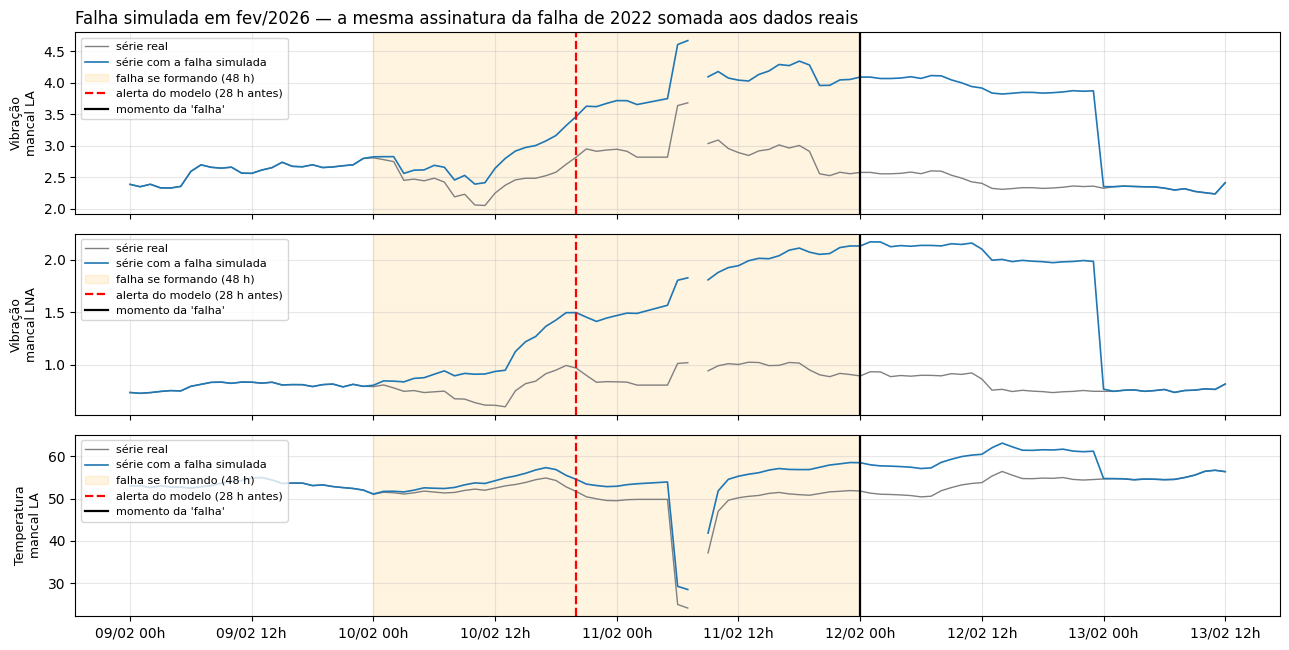

,falha simulada em,alerta,já alarmava sem a falha?
0,20/01/2026,20 h antes,não
1,10/02/2026,28 h antes,não
2,10/03/2026,14 h antes,não
3,10/06/2026,21 h antes,não
4,15/07/2026,7 h antes,não


In [4]:
sy = battery.BATTERY["B-8802B-2025"]["synthetic"]
def simular(t0):
    tf = t0 + pd.Timedelta(hours=sy["ramp_h"]); fim = tf + pd.Timedelta(hours=sy["hold_h"])
    trecho = raw.loc[t0 - pd.Timedelta(days=3): fim + pd.Timedelta(hours=12)]
    injetado = battery.inject(trecho, sy["signature"], t0, sy["ramp_h"], sy["hold_h"], 1.0)
    ai = min_duracao(alertas(injetado)); w = ai[(ai.index >= t0) & (ai.index <= fim) & ai]
    return trecho, injetado, tf, (w.index.min() if len(w) else None)

t0 = pd.Timestamp("2026-02-10")
trecho, injetado, tf, t_alerta = simular(t0)
ho = horaria(trecho.loc[t0 - pd.Timedelta(days=1):], COLS); hi_ = horaria(injetado.loc[t0 - pd.Timedelta(days=1):], COLS)
fig, axes = plt.subplots(3, 1, figsize=(13, 6.6), sharex=True)
for ax, c in zip(axes, COLS):
    ax.plot(ho.index, ho[c], color="gray", linewidth=1, label="série real")
    ax.plot(hi_.index, hi_[c], linewidth=1.2, label="série com a falha simulada")
    ax.axvspan(t0, tf, color="orange", alpha=0.12, label="falha se formando (48 h)")
    ax.axvline(t_alerta, color="red", linestyle="--", linewidth=1.6, label=f"alerta do modelo ({(tf - t_alerta).total_seconds()/3600:.0f} h antes)")
    ax.axvline(tf, color="black", linewidth=1.6, label="momento da 'falha'")
    ax.set_ylabel(rotulo(c), fontsize=9); ax.grid(alpha=0.3); ax.legend(loc="upper left", fontsize=8)
axes[0].set_title("Falha simulada em fev/2026 — a mesma assinatura da falha de 2022 somada aos dados reais", loc="left")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %Hh")); plt.tight_layout(); plt.show()

linhas = []
for d in ["2026-01-20", "2026-02-10", "2026-03-10", "2026-06-10", "2026-07-15"]:
    t = pd.Timestamp(d); _, _, tf_d, ta = simular(t)
    base = min_duracao(al_todo)[(al_todo.index >= t) & (al_todo.index <= tf_d + pd.Timedelta(hours=sy["hold_h"]))]
    linhas.append({"falha simulada em": f"{t:%d/%m/%Y}",
                   "alerta": "não detecta" if ta is None else f"{(tf_d - ta).total_seconds()/3600:.0f} h antes",
                   "já alarmava sem a falha?": "sim" if base.any() else "não"})
pd.DataFrame(linhas)

## Slide 6 — Quando o normal muda, o sistema percebe

Depois do reparo de 2022 o equipamento passou a operar de outro jeito, e o modelo de 2022 passou a alarmar sem
falha nenhuma (pontos vermelhos). O monitor de mudança de conceito compara cada dia com o normal que o modelo
aprendeu e avisa quando 3 de 5 dias seguidos ficam diferentes.

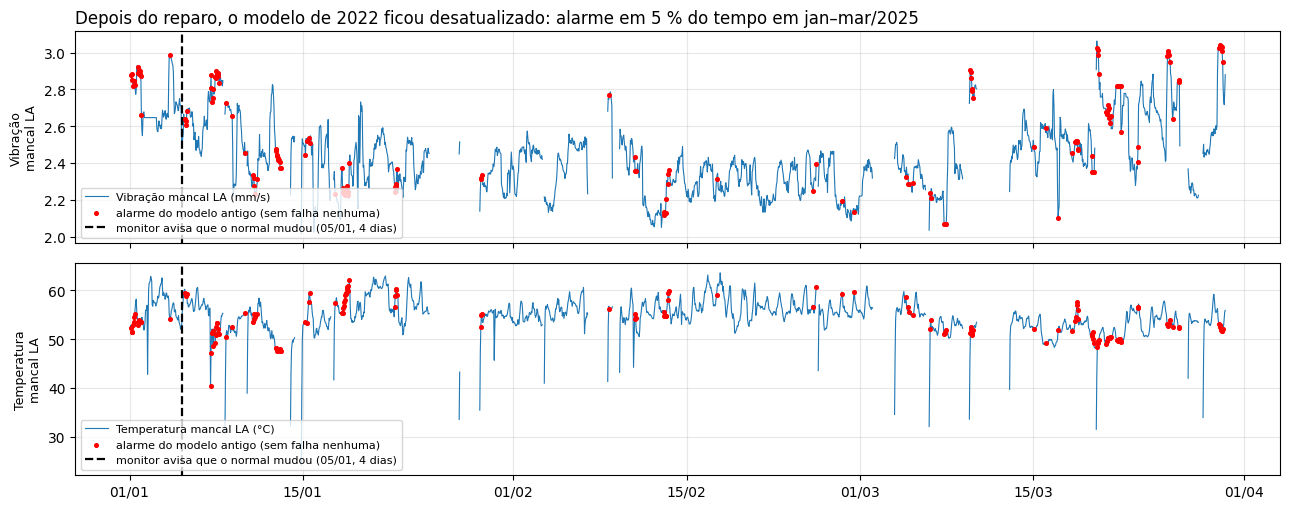

monitor avisou em 4 dias, via Vibração Bomba LA
modelo de 2022 em todo o período 2025–26: alarme em 12.2 % do tempo (sem monitor, a mudança foi percebida só 20 meses depois)


In [5]:
antigo = pd.read_csv(PROJECT_ROOT / "results/monitor_drift/b8802b_modelo2022_em_2025-26_inferencia.csv", index_col=0, parse_dates=True)
detector = CalibratedKSDetector.from_drift_ref(B_ANTIGO / "drift_ref.json")
_, disparos = detector.scan(mon._temporal_steps(B_ANTIGO, raw)); t_aviso, sensores_aviso = disparos[0]
ini, fim = "2025-01-01", "2025-03-31"
cols6 = [("Vibração Bomba LA", "Vibração mancal LA (mm/s)"), ("Temperatura Bomba LA", "Temperatura mancal LA (°C)")]
op = raw.loc[ini:fim]; op = op[op["Pressão Descarga"] > 35]
h = op[[c for c, _ in cols6]].resample("1h").mean()
al_antigo = antigo.loc[ini:fim, "is_anomaly"]; al_h = al_antigo.resample("1h").max().fillna(False).astype(bool)
fig, axes = plt.subplots(2, 1, figsize=(13, 5.2), sharex=True)
for ax, (c, nome) in zip(axes, cols6):
    ax.plot(h.index, h[c], linewidth=0.8, label=nome)
    pts = h[c][al_h.reindex(h.index).fillna(False)]
    ax.scatter(pts.index, pts.values, s=7, color="red", zorder=3, label="alarme do modelo antigo (sem falha nenhuma)")
    ax.axvline(t_aviso, color="black", linestyle="--", linewidth=1.6,
               label=f"monitor avisa que o normal mudou ({t_aviso:%d/%m}, {(t_aviso - pd.Timestamp(ini)).days} dias)")
    ax.set_ylabel(nome.split(" (")[0].replace(" mancal", "\nmancal"), fontsize=9); ax.grid(alpha=0.3); ax.legend(loc="lower left", fontsize=8)
axes[0].set_title(f"Depois do reparo, o modelo de 2022 ficou desatualizado: alarme em {100 * al_antigo.mean():.0f} % do tempo em jan–mar/2025", loc="left")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m")); plt.tight_layout(); plt.show()
print(f"monitor avisou em {(t_aviso - pd.Timestamp(ini)).days} dias, via {', '.join(sensores_aviso)}")
print(f"modelo de 2022 em todo o período 2025–26: alarme em {100 * antigo['is_anomaly'].mean():.1f} % do tempo "
      "(sem monitor, a mudança foi percebida só 20 meses depois)")

## Slide 7 — Próximos passos
1. **Adotar a regra de 1 hora:** só gera alerta o desvio que dura mais de 1 h; remove o único alerta sem desvio
   físico de 2026 (slide 3).
2. **Rodar o monitor em paralelo:** 4 semanas ao lado da produção, antes de depender dele.
3. **Verificar os 2 alertas de 2026** com a operação: 17/01 (vibração) e 10/08 (temperatura).
4. **Levar para outro equipamento:** repetir a validação onde houver histórico de falha.